# Starter code for transformations

In [26]:
# symbolic computation tools
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sympy import init_printing
init_printing() 

Analyze EOM for a 2-link system

![text](diagram.png)

In [27]:
t = symbols("t" , real = True)
l0 = symbols("l0" , real = True)
m0 = symbols("m0" , real = True)
I0_xx = symbols("I0_xx" , real = True)
I0_yy = symbols("I0_yy" , real = True)
I0_zz = symbols("I0_zz" , real = True)
l1 = symbols("l1" , real = True)
m1 = symbols("m1" , real = True)
m2 = symbols("m2" , real = True)
I1_xx = symbols("I1_xx" , real = True)
I1_yy = symbols("I1_yy" , real = True)
I1_zz = symbols("I1_zz" , real = True)
g = symbols("g" , real = True)

theta_1 = Function('theta_1', real=True)(t)
theta_0 = Function('theta_0', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)
phi = Function('phi', real=True)(t)

In [28]:
def cross_matrix(vec):
    
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)

In [29]:
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])


def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])

def inv(T):
    T_0_inv = Matrix.zeros(4,4)
    T_0_inv[0:3, 0:3] = T[0:3,0:3].T
    T_0_inv[0:3, 3] = -T[0:3,0:3].T @ T[0:3,3]
    T_0_inv[3, 3] = 1

    return T_0_inv

In [30]:
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

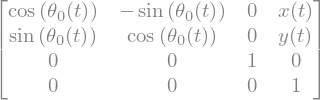

In [33]:
T_0 = T(R_z(theta_0), Matrix([[x], [y], [0]])) @ T(Matrix.eye(3,3), Matrix([[0], [0], [0]]))
T_0

### If want to tilt the pendulum
### T(R_y(-np.pi/8), Matrix([[0], [0], [0]])) @ 